##

get mean conn. pattern of visual2 parcels and plot on brain surface...

(--> group diffs? eccentricity)

In [1]:
import nilearn
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op
from brainspace.utils.parcellation import map_to_labels

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'

base_folder = op.join(bids_folder, 'derivatives' ,'dwi_connectome')
plot_folder = op.join(bids_folder, 'plots_and_ims', 'DTI')

subList = [f'{i:02d}' for i in range(1, 67)]
sub_array= np.array([int(i) for i in subList]) 

bids_folder_orig ='/mnt_03/ds-dnumrisk' 
df_participants = pd.read_csv(op.join(bids_folder_orig, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
group_list = group_list#.reset_index()


In [ ]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

In [4]:
atlas = 'Glasser_hemiUnique' #'AAL3_amended' # 

N_parcels = 360
matrix_zeros = np.zeros((N_parcels, N_parcels))
av_cm = matrix_zeros.copy()
for sub in subList:
    connectome_file = op.join(base_folder, f'sub-{sub}', 'processing', 'connectome', atlas , 'connectome.csv')
    connectome = pd.read_csv(connectome_file,header=None)
    mu_factor = pd.read_table(op.join(base_folder,f'sub-{sub}', 'processing', 'tractography/two_tissue/SIFT2_mu.txt'),header=None).values[0][0]

    C = np.array(connectome)
    C_scaled = (C + C.T) * mu_factor
    av_cm += C_scaled

av_cm /= len(subList)

In [ ]:
# mean (over parcels) network
seed_net = 2 # visual network
network_seed_indices = np.where(glasser_CAatlas_mapping['ca_network'] == seed_net)[0]

mean_net_conn_pattern = av_cm[network_seed_indices, :].mean(axis=0)
mean_net_conn_pattern[network_seed_indices] = np.nan # Set the seed network connections to zero
surf_map = map_to_labels(mean_net_conn_pattern, labeling_glasser, mask=mask_glasser, fill=np.nan) # parcel to vertex

net_name = CAatlas_names.loc[seed_net]["Network Name"]


(360,)


In [ ]:
# single parcel
parcel_n = 275
par_con_pattern = av_cm[parcel_n, :]
par_con_pattern[network_seed_indices] = np.nan # Set the seed network connections to zero
surf_map = map_to_labels(par_con_pattern, labeling_glasser, mask=mask_glasser, fill=np.nan) # parcel to vertex

net_name = f'parcel {parcel_n}'


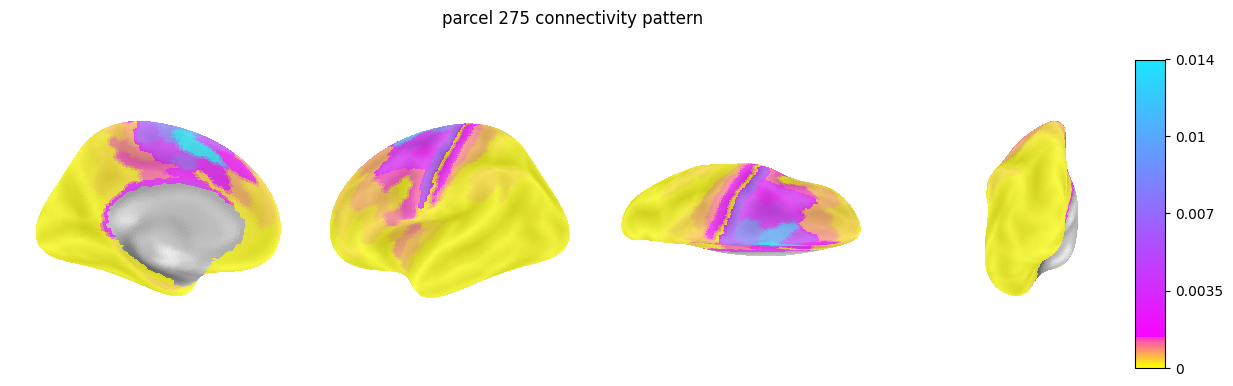

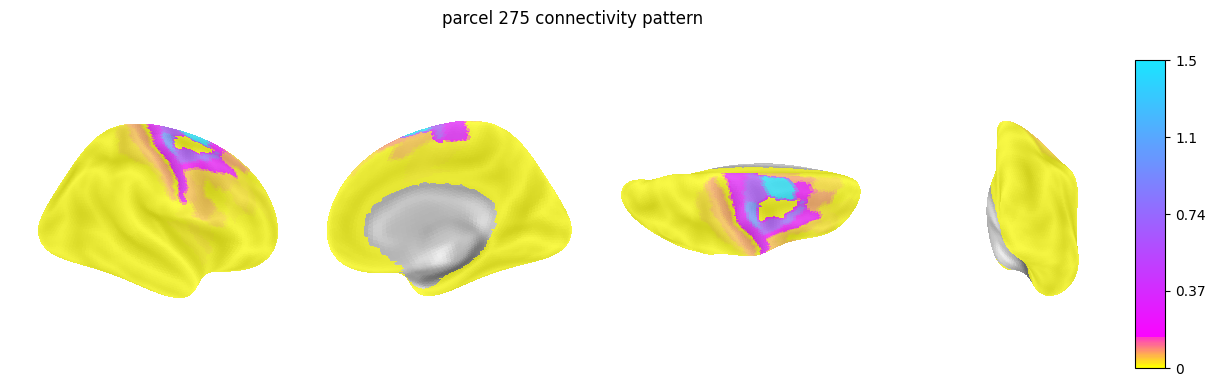

In [41]:
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt 
fsaverage = fetch_surf_fsaverage('fsaverage5') 
views = ['medial','lateral','dorsal','posterior']
cmap = 'viridis'

from numrisk.fmri_analysis.gradients.utils_02 import get_pval_colormap
cmap = get_pval_colormap()

for i, hemi in enumerate(['L','R']):
    map = np.split(surf_map,2)[i]
    surf_mesh = fsaverage.infl_right if hemi =='R' else fsaverage.infl_left
    bg_map = fsaverage.sulc_right if hemi =='R' else fsaverage.sulc_left

    figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
    for i,view in enumerate(views):
        colbar = True if view == 'posterior' else False
        nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, # infl_right # pial_right
                view= view,cmap=cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
                bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
    figure.subplots_adjust(wspace=0.01)
    figure.suptitle(f'{net_name} connectivity pattern', y=0.75)